In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [136]:
movies = pd.read_csv('/kaggle/input/datasets/sanjeethpekumar/ml-latest-small/ml-latest-small/ml-latest-small/movies.csv')

In [137]:
rating = pd.read_csv('/kaggle/input/datasets/sanjeethpekumar/ml-latest-small/ml-latest-small/ml-latest-small/ratings.csv')

In [138]:
links = pd.read_csv('/kaggle/input/datasets/sanjeethpekumar/ml-latest-small/ml-latest-small/ml-latest-small/links.csv')

In [139]:
tags = pd.read_csv('/kaggle/input/datasets/sanjeethpekumar/ml-latest-small/ml-latest-small/ml-latest-small/tags.csv')

In [140]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [141]:
rating.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [142]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [143]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [144]:
print(movies.shape)
print(rating.shape)
print(tags.shape)
print(links.shape)

(9742, 3)
(100836, 4)
(3683, 4)
(9742, 3)


In [145]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [146]:
rating.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [147]:
links.isnull().sum()

movieId    0
imdbId     0
tmdbId     8
dtype: int64

In [148]:
tags.isnull().sum()

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

In [149]:
rating.nunique()

userId         610
movieId       9724
rating          10
timestamp    85043
dtype: int64

In [150]:
movies.nunique()

movieId    9742
title      9737
genres      951
dtype: int64

In [151]:
data = pd.merge(movies,rating,on = 'movieId')

In [152]:
data.shape

(100836, 6)

In [153]:
data.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483


In [154]:
data.isnull().sum()

movieId      0
title        0
genres       0
userId       0
rating       0
timestamp    0
dtype: int64

In [155]:
#  Average Rating Per Movie
avg_rating = data.groupby('title')['rating'].mean().reset_index()

In [156]:
avg_rating.head()

,title,rating
0,'71 (2014),4.0
1,'Hellboy': The Seeds of Creation (2004),4.0
2,'Round Midnight (1986),3.5
3,'Salem's Lot (2004),5.0
4,'Til There Was You (1997),4.0


In [157]:
# Number of Ratings Per Movie
rating_count = data.groupby('title')['rating'].count().reset_index()

rating_count.tail()

,title,rating
9714,eXistenZ (1999),22
9715,xXx (2002),24
9716,xXx: State of the Union (2005),5
9717,¡Three Amigos! (1986),26
9718,À nous la liberté (Freedom for Us) (1931),1


In [158]:
rating_count.nlargest(5, 'rating')

,title,rating
3158,Forrest Gump (1994),329
7593,"Shawshank Redemption, The (1994)",317
6865,Pulp Fiction (1994),307
7680,"Silence of the Lambs, The (1991)",279
5512,"Matrix, The (1999)",278


In [159]:
# Rename Columns
avg_rating.rename({'rating': 'avg_rating'},axis = 1,inplace = True)

In [160]:
avg_rating.head()

,title,avg_rating
0,'71 (2014),4.0
1,'Hellboy': The Seeds of Creation (2004),4.0
2,'Round Midnight (1986),3.5
3,'Salem's Lot (2004),5.0
4,'Til There Was You (1997),4.0


In [161]:
rating_count.rename({'rating':'rating_count'},axis = 1,inplace = True)

In [162]:
rating_count.head()

,title,rating_count
0,'71 (2014),1
1,'Hellboy': The Seeds of Creation (2004),1
2,'Round Midnight (1986),2
3,'Salem's Lot (2004),1
4,'Til There Was You (1997),2


In [163]:
popularity = pd.merge(avg_rating,rating_count,on = 'title')

In [164]:
popularity.head()

,title,avg_rating,rating_count
0,'71 (2014),4.0,1
1,'Hellboy': The Seeds of Creation (2004),4.0,1
2,'Round Midnight (1986),3.5,2
3,'Salem's Lot (2004),5.0,1
4,'Til There Was You (1997),4.0,2


In [165]:
popularity.nlargest(5,'rating_count')

,title,avg_rating,rating_count
3158,Forrest Gump (1994),4.164134,329
7593,"Shawshank Redemption, The (1994)",4.429022,317
6865,Pulp Fiction (1994),4.197068,307
7680,"Silence of the Lambs, The (1991)",4.161290,279
5512,"Matrix, The (1999)",4.192446,278


In [166]:
popularity = popularity[popularity['rating_count'] > 50]

In [167]:
popularity.head()

,title,avg_rating,rating_count
18,10 Things I Hate About You (1999),3.527778,54
34,12 Angry Men (1957),4.149123,57
74,2001: A Space Odyssey (1968),3.894495,109
89,28 Days Later (2002),3.974138,58
104,300 (2007),3.681250,80


In [168]:
popularity.shape[0]

437

In [169]:
popular_movie = popularity.sort_values('avg_rating',ascending = False)

In [170]:
popular_movie.head()

,title,avg_rating,rating_count
7593,"Shawshank Redemption, The (1994)",4.429022,317
3499,"Godfather, The (1972)",4.289062,192
3011,Fight Club (1999),4.272936,218
1961,Cool Hand Luke (1967),4.271930,57
2531,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97


In [171]:
# Final Recommendation Function
def recomend_popular(n = 10):
    return popular_movie.head(n)

In [172]:
recomend_popular(10)

,title,avg_rating,rating_count
7593,"Shawshank Redemption, The (1994)",4.429022,317
3499,"Godfather, The (1972)",4.289062,192
3011,Fight Club (1999),4.272936,218
1961,Cool Hand Luke (1967),4.271930,57
2531,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
6999,Rear Window (1954),4.261905,84
3500,"Godfather: Part II, The (1974)",4.259690,129
2334,"Departed, The (2006)",4.252336,107
3564,Goodfellas (1990),4.250000,126
1593,Casablanca (1942),4.240000,100


In [173]:
# Rating Distribution

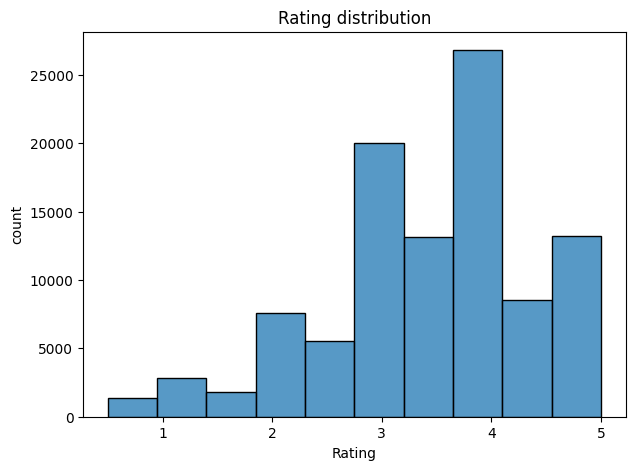

In [174]:
plt.figure(figsize = (7,5))
sns.histplot(data['rating'],bins = 10)
plt.title('Rating distribution')
plt.xlabel('Rating')
plt.ylabel('count')
plt.show()

In [175]:
#  most rating are between 3 and 4 and very few rating is below 2 users generally rate moview positively

In [176]:
rating_per_user = data.groupby('userId')['rating'].count()

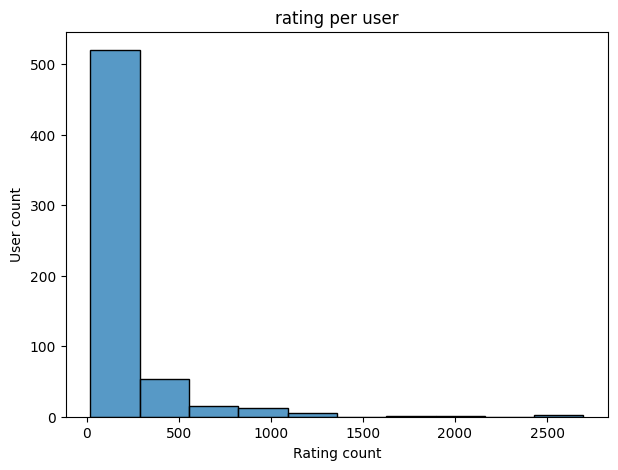

In [177]:
plt.figure(figsize = (7,5))
sns.histplot(rating_per_user,bins = 10)
plt.title('rating per user')
plt.xlabel('Rating count')
plt.ylabel('User count')
plt.show()

In [178]:
# Most users rate only a few movies Few users rate many movies Dataset is sparse

In [179]:
rating_per_movie = data.groupby('title')['rating'].count()

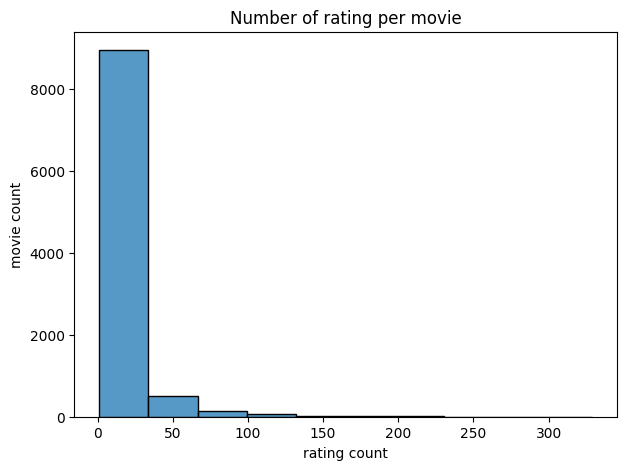

In [180]:
plt.figure(figsize = (7,5))
sns.histplot(rating_per_movie,bins = 10)
plt.title('Number of rating per movie')
plt.xlabel('rating count')
plt.ylabel('movie count')
plt.show()

In [181]:
# Few movies have very high ratings Most movies have very few ratings Popularity imbalance

In [182]:
top_movies = data.groupby('title')['rating'].count().sort_values(ascending = False).head(10)

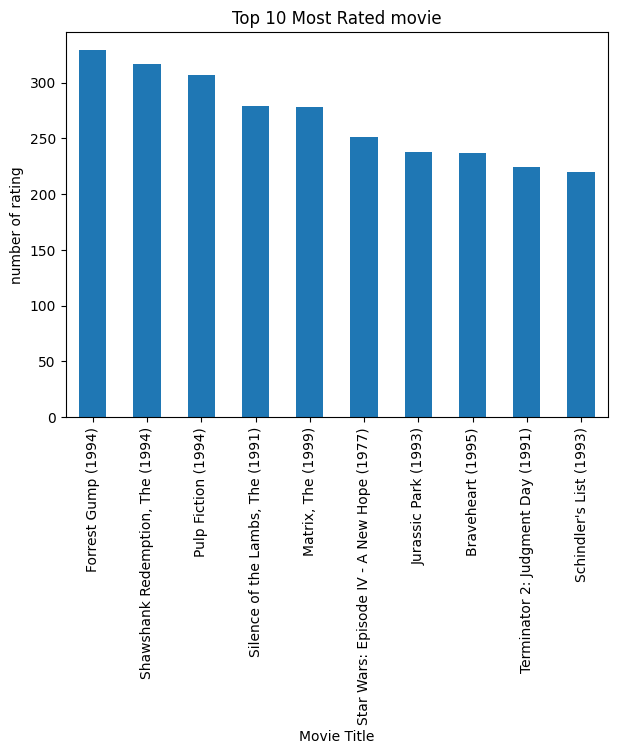

In [183]:
plt.figure(figsize = (7,5))
top_movies.plot(kind = 'bar')
plt.title('Top 10 Most Rated movie')
plt.xlabel('Movie Title')
plt.ylabel('number of rating')
plt.show()

In [184]:
# popular top 10 movie dominating rating

In [185]:
avg_movie_rating = data.groupby('title')['rating'].mean().sort_values(ascending = False).head(10)

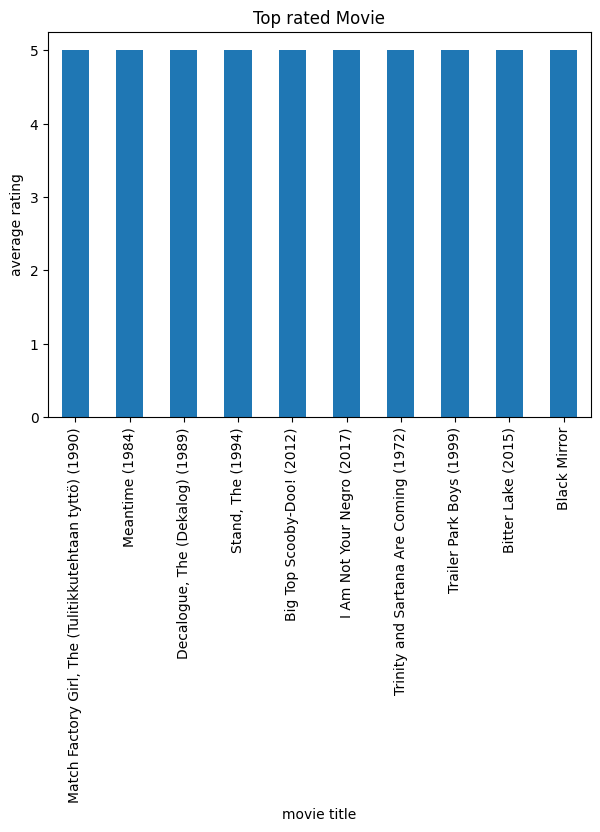

In [186]:
plt.figure(figsize = (7,5))
avg_movie_rating.plot(kind = 'bar')
plt.title('Top rated Movie')
plt.xlabel('movie title')
plt.ylabel('average rating')
plt.show()

In [187]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [188]:
genere = movies['genres'].str.split('|').explode()

In [189]:
genere

0       Adventure
0       Animation
0        Children
0          Comedy
0         Fantasy
          ...    
9738      Fantasy
9739        Drama
9740       Action
9740    Animation
9741       Comedy
Name: genres, Length: 22084, dtype: object

In [190]:
genere_counts = genere.value_counts()

In [191]:
genere_counts

genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64

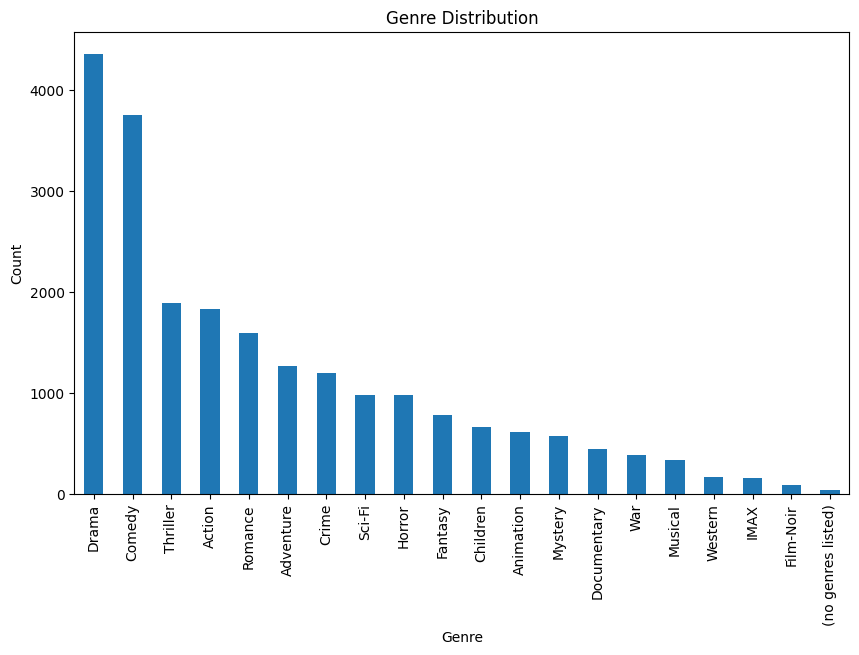

In [192]:
plt.figure(figsize=(10,6))

genere_counts.plot(kind='bar')

plt.title("Genre Distribution")

plt.xlabel("Genre")

plt.ylabel("Count")

plt.show()

In [193]:
# Drama and Comedy are most common genere

In [194]:
movie_stats = data.groupby('title').agg({'rating':['mean','count']})

In [195]:
movie_stats.columns = ['avg_rating','rating_counts']

In [196]:
movie_stats

,avg_rating,rating_counts
title,,
'71 (2014),4.000000,1
'Hellboy': The Seeds of Creation (2004),4.000000,1
'Round Midnight (1986),3.500000,2
'Salem's Lot (2004),5.000000,1
'Til There Was You (1997),4.000000,2
...,...,...
eXistenZ (1999),3.863636,22
xXx (2002),2.770833,24
xXx: State of the Union (2005),2.000000,5


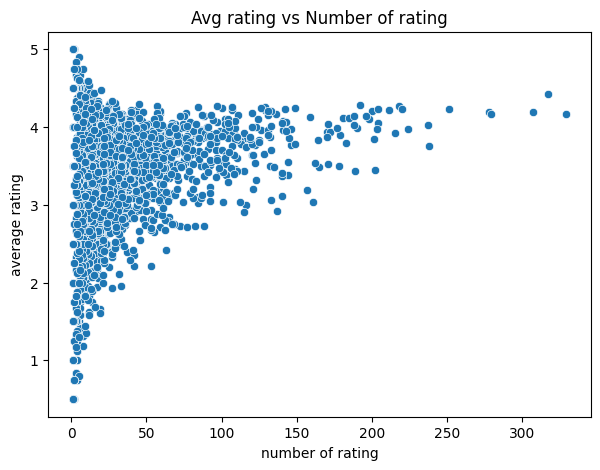

In [197]:
plt.figure(figsize = (7,5))
sns.scatterplot(x = 'rating_counts',y = 'avg_rating',data = movie_stats)
plt.title('Avg rating vs Number of rating')
plt.xlabel('number of rating')
plt.ylabel('average rating')
plt.show()

In [198]:
# Movies with very few ratings may have artificially high ratings

In [199]:
# Data Preprocessing

In [200]:
movie_stats.head()

,avg_rating,rating_counts
title,,
'71 (2014),4.0,1
'Hellboy': The Seeds of Creation (2004),4.0,1
'Round Midnight (1986),3.5,2
'Salem's Lot (2004),5.0,1
'Til There Was You (1997),4.0,2


In [201]:
movie_stats = movie_stats[movie_stats['rating_counts'] > 50]

In [202]:
movie_stats

,avg_rating,rating_counts
title,,
10 Things I Hate About You (1999),3.527778,54
12 Angry Men (1957),4.149123,57
2001: A Space Odyssey (1968),3.894495,109
28 Days Later (2002),3.974138,58
300 (2007),3.681250,80
...,...,...
X-Men: The Last Stand (2006),3.355769,52
X2: X-Men United (2003),3.723684,76
Young Frankenstein (1974),3.992754,69


In [203]:
movie_stats.shape

(437, 2)

In [204]:
data = data[data['title'].isin(movie_stats.index)]

In [205]:
data.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483


In [206]:
data.shape

(40712, 6)

In [207]:
user_stats = data.groupby('userId')['rating'].count()

In [208]:
user_stats.head()

userId
1    115
2     14
3      4
4     83
5     34
Name: rating, dtype: int64

In [209]:
# Users who rated more than 20 movies
active_user = user_stats[user_stats > 20].index

In [210]:
active_user.shape

(466,)

In [211]:
data = data[data['userId'].isin(active_user)]

In [212]:
data.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483


In [213]:
data.shape

(38907, 6)

In [214]:
print("Total Users:", data['userId'].nunique())
print("Total Movies:", data['movieId'].nunique())
print("Total Ratings:", data.shape[0])

Total Users: 466
Total Movies: 438
Total Ratings: 38907


In [215]:
# Create User-Item Matrix

In [216]:
user_movie_matrix = data.pivot_table(index = 'userId',columns = 'title',values = 'rating')

In [217]:
user_movie_matrix.head()

title,10 Things I Hate About You (1999),12 Angry Men (1957),2001: A Space Odyssey (1968),28 Days Later (2002),300 (2007),"40-Year-Old Virgin, The (2005)",A.I. Artificial Intelligence (2001),"Abyss, The (1989)",Ace Ventura: Pet Detective (1994),Ace Ventura: When Nature Calls (1995),...,Wild Wild West (1999),Willy Wonka & the Chocolate Factory (1971),"Wizard of Oz, The (1939)","Wolf of Wall Street, The (2013)",X-Men (2000),X-Men: The Last Stand (2006),X2: X-Men United (2003),Young Frankenstein (1974),Zombieland (2009),Zoolander (2001)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,...,NaN,5.0,5.0,NaN,5.0,NaN,NaN,5.0,NaN,NaN
4,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.0,...,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,4.0,NaN,NaN,NaN,4.5,NaN,NaN,NaN,...,1.5,NaN,NaN,NaN,3.5,4.0,4.0,NaN,NaN,NaN


In [218]:
user_movie_matrix.shape

(466, 437)

In [219]:
user_movie_matrix.isnull().sum()

title
10 Things I Hate About You (1999)    419
12 Angry Men (1957)                  414
2001: A Space Odyssey (1968)         363
28 Days Later (2002)                 413
300 (2007)                           390
                                    ... 
X-Men: The Last Stand (2006)         414
X2: X-Men United (2003)              392
Young Frankenstein (1974)            403
Zombieland (2009)                    417
Zoolander (2001)                     412
Length: 437, dtype: int64

In [220]:
user_movie_matrix = user_movie_matrix.fillna(0)

In [221]:
user_movie_matrix.isnull().sum()

title
10 Things I Hate About You (1999)    0
12 Angry Men (1957)                  0
2001: A Space Odyssey (1968)         0
28 Days Later (2002)                 0
300 (2007)                           0
                                    ..
X-Men: The Last Stand (2006)         0
X2: X-Men United (2003)              0
Young Frankenstein (1974)            0
Zombieland (2009)                    0
Zoolander (2001)                     0
Length: 437, dtype: int64

In [222]:
# Convert To Sparse Matrix (Important)
#Large Matrix Size: Recommendation systems often deal with extremely large matrices (example=, millions of users and items).
#Memory Efficiency: Storing these large matrices directly is memory-intensive.
#Sparse Representation: We convert the dense matrix into a sparse matrix.
#How it works: A sparse matrix stores only the non-zero values (e.g., actual user-item interactions like ratings or clicks)
#and their positions, ignoring the empty or zero values.
#Benefit: This significantly reduces memory usage and improves computational efficiency.

In [223]:
from scipy.sparse import csr_matrix
sparse_matrix = csr_matrix(user_movie_matrix)

In [224]:
# Check Sparsity
num_ratings = np.count_nonzero(user_movie_matrix)

total_cells = user_movie_matrix.shape[0] * user_movie_matrix.shape[1]

sparsity = (1 - num_ratings/total_cells) * 100

print("Sparsity:", sparsity)

Sparsity: 80.89539485960657


In [225]:
# most user rate very few movie

In [226]:
# Content Based Recommendation
# Extracting similarity based on movie genres and recommending similar movies.
# Genres → Text Processing → Vectorization → Cosine Similarity → Recommendation

In [227]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [228]:
movies['genres'] = movies['genres'].str.replace('|',' ')

In [229]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


In [230]:
# TF-IDF Vectorization

In [231]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [232]:
tfidf = TfidfVectorizer()

In [233]:
tfidf_matrix = tfidf.fit_transform(movies['genres'])

In [234]:
tfidf_matrix.shape

(9742, 24)

In [235]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23219 stored elements and shape (9742, 24)>

In [236]:
# Cosine Similarity Calculate
# Now we will find the similarity between movies

In [237]:
from sklearn.metrics.pairwise import cosine_similarity

In [238]:
cosine_sim = cosine_similarity(tfidf_matrix,tfidf_matrix)

In [239]:
# Movie vs Movie similarity matrix
cosine_sim.shape

(9742, 9742)

In [240]:
# Let's create a movie index map for the recommendation function

In [241]:
movie_indices = pd.Series(movies.index,index = movies['title']).drop_duplicates()

In [242]:
movie_indices['Toy Story (1995)']

np.int64(0)

In [243]:
# Now we will create the main recommendation function.

In [244]:
def recommend_movies(title, num_recommendations=10):
    
    idx = movie_indices[title]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:num_recommendations+1]
    
    movie_indices_sim = [i[0] for i in sim_scores]
    
    return movies['title'].iloc[movie_indices_sim]

In [245]:
recommend_movies("Toy Story (1995)")

1706                                          Antz (1998)
2355                                   Toy Story 2 (1999)
2809       Adventures of Rocky and Bullwinkle, The (2000)
3000                     Emperor's New Groove, The (2000)
3568                                Monsters, Inc. (2001)
6194                                     Wild, The (2006)
6486                               Shrek the Third (2007)
6948                       Tale of Despereaux, The (2008)
7760    Asterix and the Vikings (Astérix et les Viking...
8219                                         Turbo (2013)
Name: title, dtype: object

In [246]:
# Collaborative Filtering (KNN)
# This system will provide recommendations based on user behavior.
# User A liked → Avengers
# Similar users liked → Iron Man

In [247]:
from sklearn.neighbors import NearestNeighbors

In [248]:
movie_user_matrix = user_movie_matrix.T

In [249]:
from scipy.sparse import csr_matrix

movie_user_sparse = csr_matrix(movie_user_matrix.values)

In [250]:
from sklearn.neighbors import NearestNeighbors

knn_model = NearestNeighbors(metric='cosine', algorithm='brute')

knn_model.fit(movie_user_sparse)

NearestNeighbors(algorithm='brute', metric='cosine')

In [251]:
def recommend_knn(movie_name, n_recommendations=5):
    
    movie_list = movie_user_matrix.index
    
    movie_idx = movie_list.get_loc(movie_name)
    
    distances, indices = knn_model.kneighbors(
        movie_user_matrix.iloc[movie_idx,:].values.reshape(1,-1),
        n_neighbors=n_recommendations+1
    )
    
    recommendations = []
    
    for i in range(1, len(indices.flatten())):
        recommendations.append(movie_list[indices.flatten()[i]])
        
    return recommendations

In [252]:
recommend_knn("Toy Story (1995)")

['Jurassic Park (1993)',
 'Toy Story 2 (1999)',
 'Forrest Gump (1994)',
 'Star Wars: Episode IV - A New Hope (1977)',
 'Star Wars: Episode VI - Return of the Jedi (1983)']

In [261]:
# Matrix Factorization (SVD)

In [256]:
from sklearn.decomposition import TruncatedSVD

In [266]:
movie_matrix = user_movie_matrix.T

In [267]:


svd = TruncatedSVD(n_components=50)

matrix_svd = svd.fit_transform(movie_matrix)

In [268]:
matrix_svd.shape

(437, 50)

In [269]:
corr_matrix = np.corrcoef(matrix_svd)

In [270]:
def recommend_svd(movie_name, n_recommendations=10):
    
    movie_index = movie_matrix.index.get_loc(movie_name)
    
    corr_movie = corr_matrix[movie_index]
    
    similar_indices = np.argsort(corr_movie)[::-1][1:n_recommendations+1]
    
    return movie_matrix.index[similar_indices]

In [271]:
recommend_svd("Toy Story (1995)")

Index(['Toy Story 2 (1999)', 'Jurassic Park (1993)', 'Bug's Life, A (1998)',
       'Shrek (2001)', 'Aladdin (1992)', 'Babe (1995)',
       'Independence Day (a.k.a. ID4) (1996)', 'Apollo 13 (1995)',
       'Groundhog Day (1993)', 'Lion King, The (1994)'],
      dtype='object', name='title')

In [272]:
#Content Based → movie similarity
#KNN → user behaviour similarity
#SVD → latent preferences

In [273]:
def recommend_content(movie_name, n=10):

    idx = movie_indices[movie_name]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:n+1]

    movie_indices_sim = [i[0] for i in sim_scores]

    return movies['title'].iloc[movie_indices_sim]

In [274]:
def recommend_knn(movie_name, n=10):

    movie_list = movie_user_matrix.index

    movie_idx = movie_list.get_loc(movie_name)

    distances, indices = knn_model.kneighbors(
        movie_user_matrix.iloc[movie_idx,:].values.reshape(1,-1),
        n_neighbors=n+1
    )

    recommendations = []

    for i in range(1, len(indices.flatten())):

        recommendations.append(movie_list[indices.flatten()[i]])

    return recommendations

In [275]:
def recommend_svd(movie_name, n=10):

    movie_index = movie_matrix.index.get_loc(movie_name)

    corr_movie = corr_matrix[movie_index]

    similar_indices = np.argsort(corr_movie)[::-1][1:n+1]

    return movie_matrix.index[similar_indices]

In [276]:
def hybrid_recommend(movie_name, n=10):

    content_rec = list(recommend_content(movie_name, n))

    knn_rec = list(recommend_knn(movie_name, n))

    svd_rec = list(recommend_svd(movie_name, n))

    combined = content_rec + knn_rec + svd_rec

    final_recommendations = list(set(combined))

    return final_recommendations[:n]

In [277]:
hybrid_recommend("Toy Story (1995)")

["Bug's Life, A (1998)",
 'Antz (1998)',
 'Independence Day (a.k.a. ID4) (1996)',
 'Wild, The (2006)',
 'Shrek the Third (2007)',
 'Apollo 13 (1995)',
 'Back to the Future (1985)',
 'Turbo (2013)',
 'Groundhog Day (1993)',
 'Forrest Gump (1994)']

In [278]:
#Uses movie features Uses user behaviour Uses latent factors

In [279]:
import pickle

pickle.dump(movies,open("movies.pkl","wb"))
pickle.dump(movie_indices,open("movie_indices.pkl","wb"))
pickle.dump(cosine_sim,open("cosine_sim.pkl","wb"))
pickle.dump(knn_model,open("knn_model.pkl","wb"))
pickle.dump(movie_user_matrix,open("movie_user_matrix.pkl","wb"))
pickle.dump(movie_matrix,open("movie_matrix.pkl","wb"))
pickle.dump(corr_matrix,open("corr_matrix.pkl","wb"))